# Phan tich da bien: Persona Analysis

Muc tieu:
- Su dung 3 bien: `What is your current occupation`, `Specialization`, `Converted`.
- Xac dinh to hop nghe nghiep + chuyen mon co ty le converd cao.

Bieu do:
- Heatmap ty le `% Converted` theo cap `Occupation x Specialization`.
- 100% Stacked Bar so sanh co cau `Converted` vs `Not Converted` theo `Occupation`.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Cau hinh hien thi
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 50)
sns.set_theme(style='whitegrid')

# Doc du lieu
file_path = 'Cleaned_Leads.csv'
df = pd.read_csv(file_path)

# Chon bien phan tich
occ_col = 'What is your current occupation'
spec_col = 'Specialization'
conv_col = 'Converted'

# Lam sach du lieu co ban
df[occ_col] = df[occ_col].fillna('Unknown').astype(str).str.strip()
df[spec_col] = df[spec_col].fillna('Unknown').astype(str).str.strip()
df[conv_col] = pd.to_numeric(df[conv_col], errors='coerce').fillna(0).astype(int)

print(f'So dong du lieu: {len(df):,}')
print(f'Ty le Converted tong the: {df[conv_col].mean() * 100:.2f}%')


So dong du lieu: 7,690
Ty le chuyen doi tong the: 39.73%


In [ ]:
# Tong hop theo cap Occupation x Specialization
pair_summary = (
    df.groupby([occ_col, spec_col], dropna=False)
      .agg(
          total_leads=(conv_col, 'size'),
          converted_leads=(conv_col, 'sum')
      )
      .reset_index()
)
pair_summary['conversion_rate_pct'] = pair_summary['converted_leads'] / pair_summary['total_leads'] * 100

# Loc nhom co du kich thuoc mau de ket luan on dinh
min_sample = 20
pair_filtered = pair_summary[pair_summary['total_leads'] >= min_sample].copy()

# Top nhom theo ty le chuyen doi
top_by_rate = pair_filtered.sort_values(
    ['conversion_rate_pct', 'converted_leads'],
    ascending=[False, False]
).head(15)

# Top nhom theo so luong converted
pair_large = pair_summary[pair_summary['total_leads'] >= 50].copy()
top_by_volume = pair_large.sort_values(
    ['converted_leads', 'conversion_rate_pct'],
    ascending=[False, False]
).head(15)

# Tong hop theo occupation
occupation_summary = (
    df.groupby(occ_col)
      .agg(total_leads=(conv_col, 'size'), converted_leads=(conv_col, 'sum'))
      .reset_index()
)
occupation_summary['conversion_rate_pct'] = occupation_summary['converted_leads'] / occupation_summary['total_leads'] * 100
occupation_summary = occupation_summary.sort_values('conversion_rate_pct', ascending=False)

print('=== Occupation Summary ===')
display(occupation_summary)

print('\n=== Top combinations by conversion rate (n >= 20) ===')
display(top_by_rate)

print('\n=== Top combinations by converted volume (n >= 50) ===')
display(top_by_volume)


=== Occupation Summary ===


,What is your current occupation,total_leads,converted_leads,conversion_rate_pct
1,Housewife,10,10,100.000000
6,Working Professional,620,562,90.645161
0,Businessman,8,5,62.500000
2,Other,16,10,62.500000
3,Student,179,75,41.899441
4,Unemployed,4951,2072,41.850131
5,Unknown,1906,321,16.841553



=== Top combinations by conversion rate (n >= 20) ===


,What is your current occupation,Specialization,total_leads,converted_leads,conversion_rate_pct
90,Working Professional,Operations Management,69,68,98.550725
86,Working Professional,IT Projects Management,35,34,97.142857
78,Working Professional,"Banking, Investment And Insurance",29,28,96.551724
83,Working Professional,Healthcare Management,24,23,95.833333
79,Working Professional,Business Administration,42,40,95.238095
82,Working Professional,Finance Management,94,89,94.680851
95,Working Professional,Supply Chain Management,43,40,93.023256
88,Working Professional,Marketing Management,87,78,89.655172
85,Working Professional,Human Resource Management,80,69,86.250000
84,Working Professional,Hospitality Management,20,17,85.000000



=== Top combinations by converted volume (n >= 50) ===


,What is your current occupation,Specialization,total_leads,converted_leads,conversion_rate_pct
54,Unemployed,Select,1227,469,38.223309
43,Unemployed,Finance Management,614,266,43.322476
49,Unemployed,Marketing Management,521,247,47.408829
46,Unemployed,Human Resource Management,546,242,44.322344
51,Unemployed,Operations Management,307,132,42.996743
40,Unemployed,Business Administration,254,110,43.307087
39,Unemployed,"Banking, Investment And Insurance",216,107,49.537037
77,Unknown,Unknown,637,102,16.012559
56,Unemployed,Supply Chain Management,228,97,42.543860
47,Unemployed,IT Projects Management,234,92,39.316239


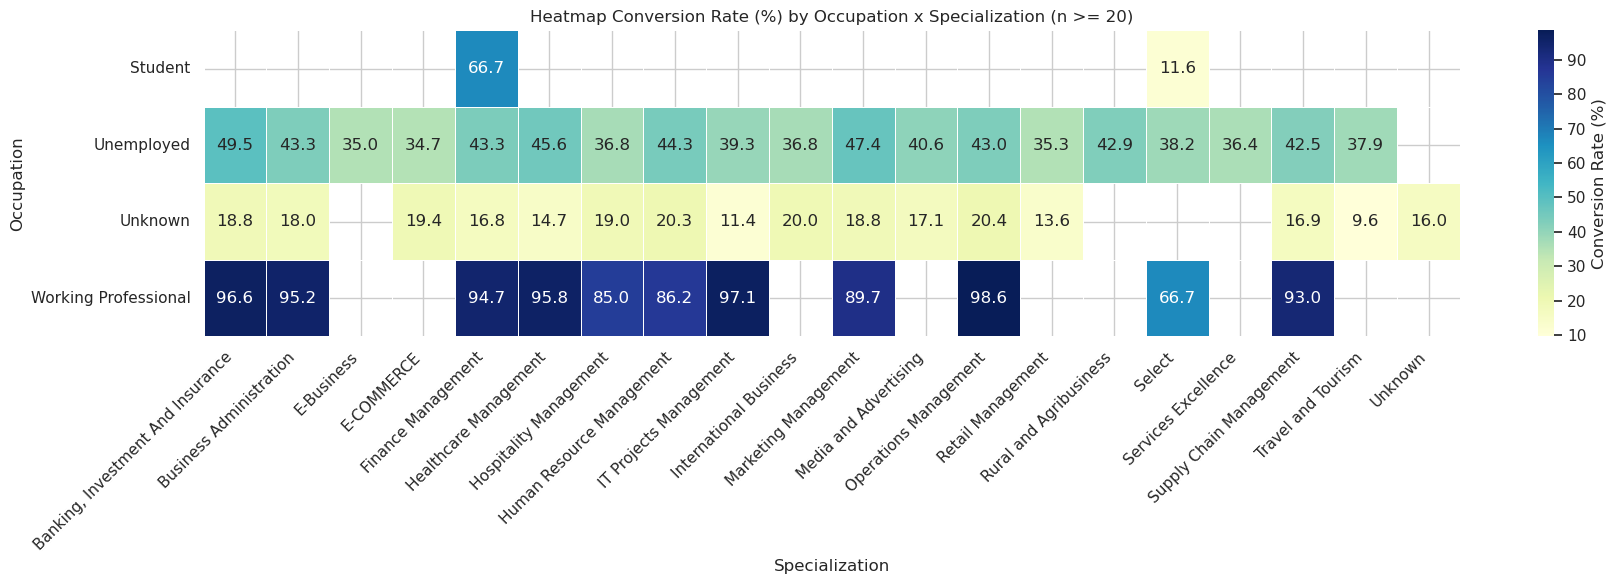

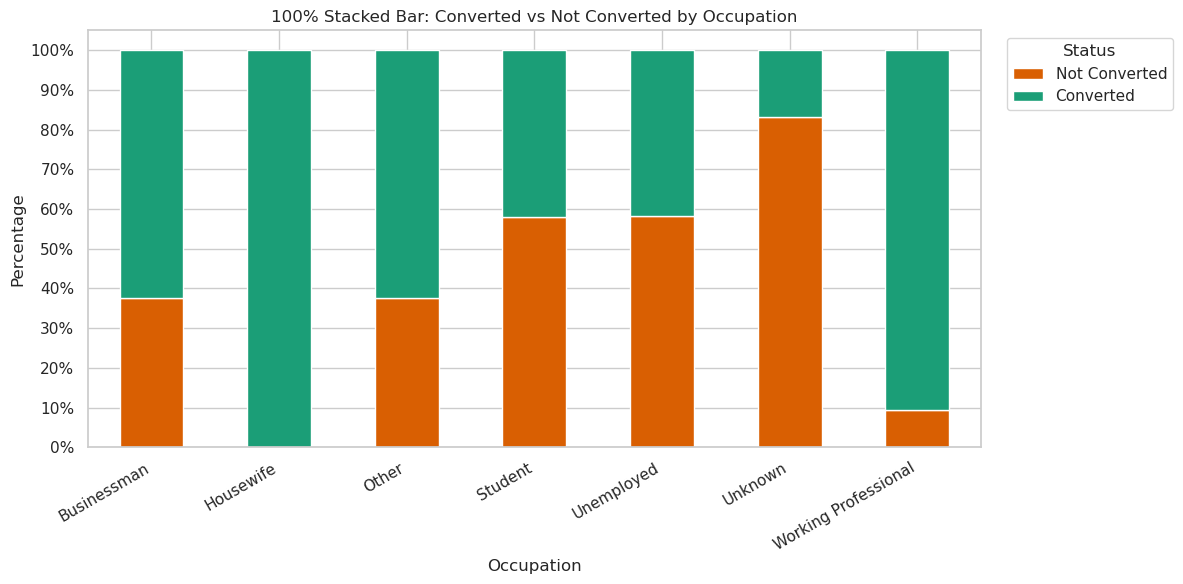

In [ ]:
# Heatmap: ty le chuyen doi theo Occupation x Specialization
heatmap_df = pair_filtered.pivot(
    index=occ_col,
    columns=spec_col,
    values='conversion_rate_pct'
)

plt.figure(figsize=(18, 6))
sns.heatmap(
    heatmap_df,
    annot=True,
    fmt='.1f',
    cmap='YlGnBu',
    linewidths=0.5,
    cbar_kws={'label': 'Conversion Rate (%)'}
)
plt.title('Heatmap Conversion Rate (%) by Occupation x Specialization (n >= 20)')
plt.xlabel('Specialization')
plt.ylabel('Occupation')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

#  co cau Converted / Not Converted theo Occupation
stacked = (
    df.groupby(occ_col)[conv_col]
      .value_counts(normalize=True)
      .rename('ratio')
      .reset_index()
)
stacked['status'] = stacked[conv_col].map({1: 'Converted', 0: 'Not Converted'})

stack_pivot = stacked.pivot(index=occ_col, columns='status', values='ratio').fillna(0)

# Dam bao thu tu cot cho de doc
for col in ['Not Converted', 'Converted']:
    if col not in stack_pivot.columns:
        stack_pivot[col] = 0
stack_pivot = stack_pivot[['Not Converted', 'Converted']]

ax = stack_pivot.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6),
    color=['#d95f02', '#1b9e77']
)
plt.title('100% Stacked Bar: Converted vs Not Converted by Occupation')
plt.xlabel('Occupation')
plt.ylabel('Percentage')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Status', bbox_to_anchor=(1.02, 1), loc='upper left')

# Hien thi truc y theo dang %
y_ticks = [i / 10 for i in range(0, 11)]
plt.yticks(y_ticks, [f'{int(i*100)}%' for i in y_ticks])
plt.tight_layout()
plt.show()


# Giai thich bieu do

## 1) Danh gia tu Heatmap (Occupation x Specialization)

- Nhom Working Professional co conversion rate cao va on dinh o nhieu specialization, noi bat nhu Operations Management (~98.6%), IT Projects Management (~97.1%), Banking/Investment/Insurance (~96.6%), Business Administration (~95.2%), Healthcare Management (~95.8%), Finance Management (~94.7%) va Supply Chain Management (~93.0%).
- Nhom Unemployed co conversion rate trung binh (da so quanh 35% - 49%), cao nhat gan 49.5% (Banking/Investment/Insurance) va khoang 47.4% (Marketing Management).
- Nhom Unknown co conversion rate thap (chu yeu 10% - 20%), cho thay chat luong lead hoac do day du thong tin cua nhom nay khong cao.
- Nhom Student khong dong deu theo specialization: co diem cao o Finance Management (~66.7%) nhung rat thap o Select (~11.6%).

=> Y nghia: Occupation la bien phan tach rat manh. Working Professional la persona co muc do san sang chuyen doi cao nhat; trong khi Unknown va mot phan Student can chien luoc nuoi duong/lam sach du lieu truoc khi ky vong conversion cao.

## 2) Danh gia tu 100% Stacked Bar (Converted vs Not Converted theo Occupation)

- Working Professional co ty trong Converted rat cao (xap xi 90%), dong nhat voi ket qua heatmap.
- Unknown co ty trong Converted thap nhat (chi quanh 17%), phan Not Converted chiem da so (khoang 83%).
- Student va Unemployed co co cau gan giong nhau, Converted chi quanh 42%, nghia la con du dia toi uu lon.
- Businessman va Other co ty le Converted kha hon (khoang 62%).
- Housewife hien thi gan 100% Converted, nhung can kiem tra quy mo mau truoc khi ket luan manh vi nhom nay co the rat it quan sat.

## 3) Ket luan quan tri

1. Uu tien ngan sach va sales effort vao segment Working Professional (dac biet cac specialization dang cao >90%).
2. Tach rieng nhom Unknown de bo sung du lieu ho so (occupation/specialization) va chay chuong trinh qualification truoc.
3. Voi Student va Unemployed, can thiet ke thong diep theo specialization (khong nen danh dong loat) vi conversion dao dong manh giua cac nhanh.
4. Khi ra quyet dinh kinh doanh, luon doi chieu them quy mo mau (n) de tranh overfit voi cac nhom co so luong nho.

## 2) Phan tich Kenh tiep can va Hanh vi (Channel-Behavior Interaction)

Bien phan tich:
- Lead Source
- Total Time Spent on Website
- TotalVisits
- Converted

Muc tieu:
- Danh gia Google co dem lai lead o lai web lau hon va de chuyen doi hon so voi Direct Traffic hay khong.
- Truc quan hoa bang Facet Grid Scatter Plot (X: Time on Website, Y: TotalVisits, hue: Converted).

In [ ]:
# Chuan bi du lieu cho phan tich kenh tiep can
source_col = 'Lead Source'
time_col = 'Total Time Spent on Website'
visit_col = 'TotalVisits'

channel_df = df[[source_col, time_col, visit_col, conv_col]].copy()
channel_df[source_col] = channel_df[source_col].fillna('Unknown').astype(str).str.strip()
channel_df[time_col] = pd.to_numeric(channel_df[time_col], errors='coerce').fillna(0)
channel_df[visit_col] = pd.to_numeric(channel_df[visit_col], errors='coerce').fillna(0)

# Chuan hoa ten lead source de tranh tach nhom do khac biet viet hoa/viet thuong
source_norm = channel_df[source_col].str.lower()
channel_df[source_col] = source_norm.replace({
    'google': 'Google',
    'direct traffic': 'Direct Traffic',
    'organic search': 'Organic Search',
    'olark chat': 'Olark Chat',
    'reference': 'Reference',
    'referral sites': 'Referral Sites'
})

# Loai bot outlier cuc lon de bieu do de doc hon (giu 99th percentile)
time_cap = channel_df[time_col].quantile(0.99)
visit_cap = channel_df[visit_col].quantile(0.99)
channel_plot_df = channel_df[
    (channel_df[time_col] <= time_cap) &
    (channel_df[visit_col] <= visit_cap)
].copy()

# So sanh truc tiep Google va Direct Traffic
target_sources = ['Google', 'Direct Traffic']
compare_df = channel_df[channel_df[source_col].isin(target_sources)].copy()

compare_summary = (
    compare_df.groupby(source_col)
    .agg(
        leads=('Converted', 'size'),
        avg_time_spent=(time_col, 'mean'),
        median_time_spent=(time_col, 'median'),
        avg_total_visits=(visit_col, 'mean'),
        conversion_rate_pct=(conv_col, 'mean')
    )
    .reset_index()
)
compare_summary['conversion_rate_pct'] = compare_summary['conversion_rate_pct'] * 100

print('=== Google vs Direct Traffic Summary ===')
display(compare_summary.sort_values('conversion_rate_pct', ascending=False))

# Chon top lead sources de ve facet grid
top_sources = channel_df[source_col].value_counts().head(6).index.tolist()
facet_df = channel_plot_df[channel_plot_df[source_col].isin(top_sources)].copy()
print('Top lead sources duoc dua vao Facet Grid:', top_sources)


=== Google vs Direct Traffic Summary ===


,Lead Source,leads,avg_time_spent,median_time_spent,avg_total_visits,conversion_rate_pct
1,Google,2872,655.625000,439.0,4.222841,39.937326
0,Direct Traffic,2543,605.907196,362.0,4.200157,32.166732


Top lead sources duoc dua vao Facet Grid: ['Google', 'Direct Traffic', 'Organic Search', 'Olark Chat', 'Reference', 'Referral Sites']


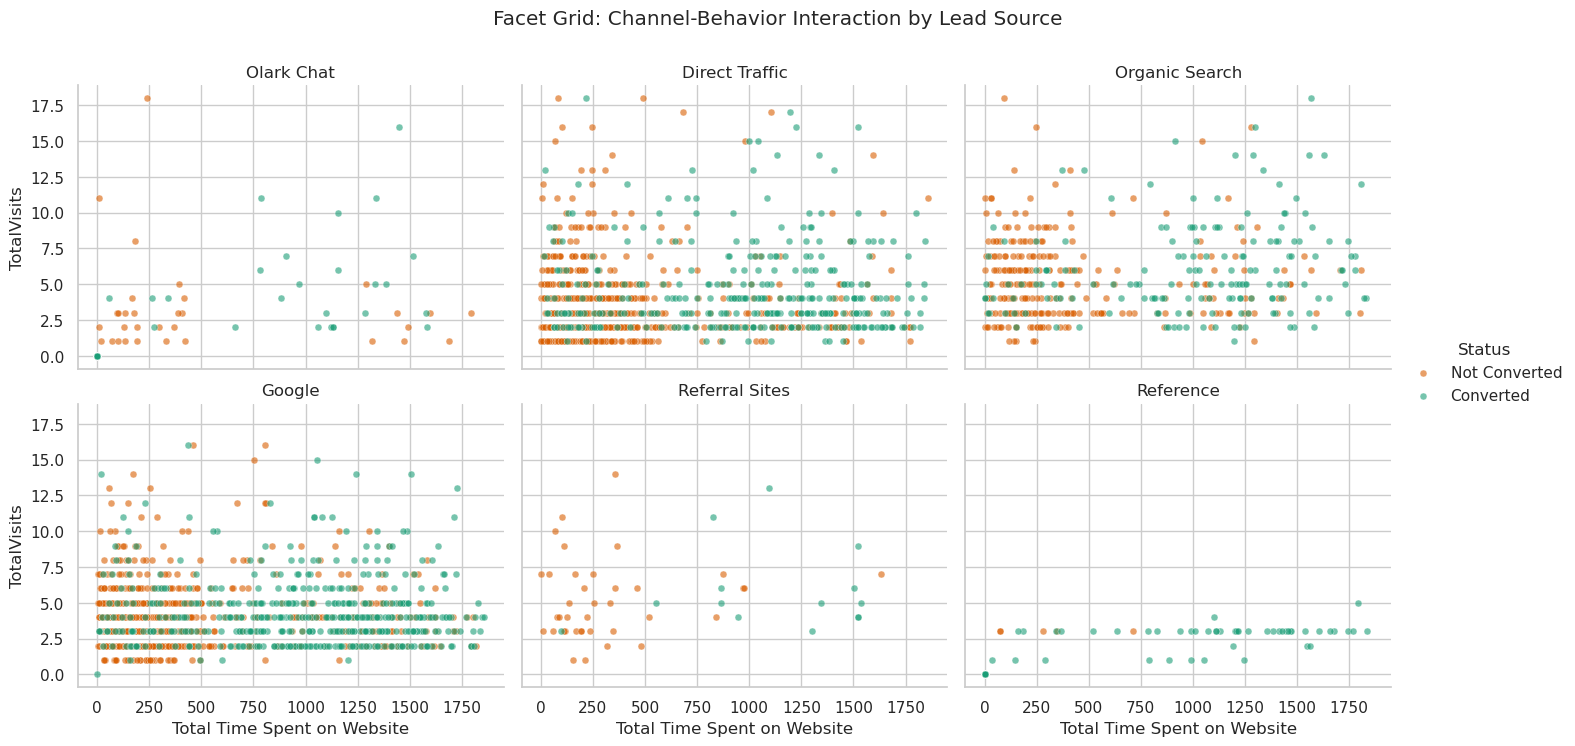


=== Quick Insight: Google vs Direct Traffic ===
Google - Avg Time: 655.6, Conversion Rate: 39.94%
Direct Traffic - Avg Time: 605.9, Conversion Rate: 32.17%
=> Google dang vuot troi hon Direct Traffic o ca thoi gian o lai va ty le chuyen doi.


In [ ]:
# Facet Grid Scatter Plot: Time Spent x TotalVisits, hue theo Converted
plot_df = facet_df.copy()
plot_df['Converted Label'] = plot_df[conv_col].map({1: 'Converted', 0: 'Not Converted'})

# Lay mau ngau nhien neu qua nhieu diem de bieu do de nhin
max_points = 3000
if len(plot_df) > max_points:
    plot_df = plot_df.sample(max_points, random_state=42)

g = sns.FacetGrid(
    plot_df,
    col=source_col,
    col_wrap=3,
    hue='Converted Label',
    height=3.8,
    aspect=1.25,
    palette={'Converted': '#1b9e77', 'Not Converted': '#d95f02'}
)
g.map_dataframe(
    sns.scatterplot,
    x=time_col,
    y=visit_col,
    alpha=0.6,
    s=25
)
g.add_legend(title='Status')
g.set_axis_labels('Total Time Spent on Website', 'TotalVisits')
g.set_titles(col_template='{col_name}')
plt.subplots_adjust(top=0.88)
g.fig.suptitle('Facet Grid: Channel-Behavior Interaction by Lead Source')
plt.show()

# Ket luan nhanh cho Google vs Direct Traffic
if not compare_summary.empty and {'google', 'direct traffic'}.issubset(set(compare_summary[source_col].str.lower())):
    normalized = compare_summary.copy()
    normalized['_source_lower'] = normalized[source_col].str.lower()
    google_row = normalized[normalized['_source_lower'] == 'google'].iloc[0]
    direct_row = normalized[normalized['_source_lower'] == 'direct traffic'].iloc[0]

    print('\n=== Quick Insight: Google vs Direct Traffic ===')
    print(f"Google - Avg Time: {google_row['avg_time_spent']:.1f}, Conversion Rate: {google_row['conversion_rate_pct']:.2f}%")
    print(f"Direct Traffic - Avg Time: {direct_row['avg_time_spent']:.1f}, Conversion Rate: {direct_row['conversion_rate_pct']:.2f}%")

    if google_row['avg_time_spent'] > direct_row['avg_time_spent'] and google_row['conversion_rate_pct'] > direct_row['conversion_rate_pct']:
        print('=> Google dang vuot troi hon Direct Traffic o ca thoi gian o lai va ty le chuyen doi.')
    elif google_row['avg_time_spent'] > direct_row['avg_time_spent']:
        print('=> Google co thoi gian o lai cao hon, nhung can kiem tra them yeu to toi uu chuyen doi.')
    elif google_row['conversion_rate_pct'] > direct_row['conversion_rate_pct']:
        print('=> Google co ty le chuyen doi cao hon, du thoi gian o lai chua vuot Direct Traffic.')
    else:
        print('=> Direct Traffic hien dang hieu qua hon hoac tuong duong Google trong du lieu hien tai.')
else:
    print('\nKhong du du lieu de so sanh truc tiep Google va Direct Traffic.')


### Danh gia ngan gon bieu do tren (Lead Source x Hanh vi)

- Nhìn chung, lead co `Total Time Spent on Website` cao hon co xu huong `Converted` nhieu hon.
- `Google` va `Organic Search` cho thay nhieu diem Converted o vung thoi gian o lai trung binh-cao, goi y chat luong traffic tot hon.
- `Direct Traffic` co phan bo Converted/Not Converted xen ke manh, can toi uu them thong diep va dieu huong trang dich.
- Cac kenh it mau nhu `Olark Chat`, `Referral Sites`, `Reference` chi nen xem la tin hieu tham khao; can kiem tra them bang ty le conversion va kich thuoc mau truoc khi ket luan ngan sach.

## 3) Phan tich Pheu chuyen doi va Tuong tac cuoi (Engagement Analysis)

Bien phan tich:
- Last Activity
- Last Notable Activity
- Converted

Muc tieu:
- Danh gia su nhat quan trong hanh vi cuoi cua lead.
- Tim ra cac chuoi hanh dong (Last Activity -> Last Notable Activity) co ty le chuyen doi cao, hay co the xem la "chuoi hanh dong vang".

In [ ]:
# Crosstab giua Last Activity va Last Notable Activity
last_act_col = 'Last Activity'
last_note_col = 'Last Notable Activity'

eng_df = df[[last_act_col, last_note_col, conv_col]].copy()
eng_df[last_act_col] = eng_df[last_act_col].fillna('Unknown').astype(str).str.strip()
eng_df[last_note_col] = eng_df[last_note_col].fillna('Unknown').astype(str).str.strip()
eng_df[conv_col] = pd.to_numeric(eng_df[conv_col], errors='coerce').fillna(0).astype(int)

# Bang cheo so luong lead
total_crosstab = pd.crosstab(eng_df[last_act_col], eng_df[last_note_col])

# Bang cheo so luong lead da converted
converted_crosstab = pd.crosstab(
    eng_df.loc[eng_df[conv_col] == 1, last_act_col],
    eng_df.loc[eng_df[conv_col] == 1, last_note_col]
)

# Ty le converted (%) tren tung cap hanh vi
conversion_rate_crosstab = (converted_crosstab / total_crosstab * 100).fillna(0)

print('=== Crosstab: Total Leads ===')
display(total_crosstab)

print('\n=== Crosstab: Converted Leads ===')
display(converted_crosstab)

print('\n=== Crosstab: Conversion Rate (%) ===')
display(conversion_rate_crosstab.round(2))

# Tim cac chuoi hanh dong co y nghia (co du kich thuoc mau)
sequence_summary = (
    eng_df.groupby([last_act_col, last_note_col])
    .agg(
        total_leads=(conv_col, 'size'),
        converted_leads=(conv_col, 'sum')
    )
    .reset_index()
)
sequence_summary['conversion_rate_pct'] = sequence_summary['converted_leads'] / sequence_summary['total_leads'] * 100

min_sequence_size = 20
golden_sequences = sequence_summary[sequence_summary['total_leads'] >= min_sequence_size].copy()
golden_sequences = golden_sequences.sort_values(
    ['conversion_rate_pct', 'converted_leads'],
    ascending=[False, False]
)

print(f"\n=== Top 'Golden Sequences' (n >= {min_sequence_size}) ===")
display(golden_sequences.head(20))

# Kiem tra truong hop nhat quan SMS Sent -> SMS Sent
sms_pair = sequence_summary[
    (sequence_summary[last_act_col].str.lower() == 'sms sent') &
    (sequence_summary[last_note_col].str.lower() == 'sms sent')
]

print('\n=== Check SMS Sent -> SMS Sent ===')
if not sms_pair.empty:
    row = sms_pair.iloc[0]
    print(
        f"Total Leads: {int(row['total_leads'])}, "
        f"Converted: {int(row['converted_leads'])}, "
        f"Conversion Rate: {row['conversion_rate_pct']:.2f}%"
    )
else:
    print('Khong tim thay cap SMS Sent -> SMS Sent trong du lieu.')


=== Crosstab: Total Leads ===


Last Notable Activity,Approached upfront,Email Bounced,Email Link Clicked,Email Marked Spam,Email Opened,Email Received,Form Submitted on Website,Had a Phone Conversation,Modified,Olark Chat Conversation,Page Visited on Website,Resubscribed to emails,SMS Sent,Unreachable,Unsubscribed,View in browser link Clicked
Last Activity,,,,,,,,,,,,,,,,
Approached upfront,1,0,0,0,0,0,0,0,7,0,0,0,0,0,0,0
Converted to Lead,0,0,0,0,0,0,0,0,427,0,0,0,0,0,0,0
Email Bounced,0,57,0,0,0,0,0,0,242,0,0,0,0,0,0,0
Email Link Clicked,0,0,134,0,0,0,0,0,81,0,0,0,0,0,0,0
Email Marked Spam,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0
Email Opened,0,0,0,0,2433,0,0,0,511,0,0,0,0,0,0,0
Email Received,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0
Form Submitted on Website,0,0,0,0,0,0,1,0,115,0,0,0,0,0,0,0
Had a Phone Conversation,0,0,0,0,0,0,0,14,16,0,0,0,0,0,0,0



=== Crosstab: Converted Leads ===


Last Notable Activity,Approached upfront,Email Bounced,Email Link Clicked,Email Marked Spam,Email Opened,Email Received,Had a Phone Conversation,Modified,Olark Chat Conversation,Page Visited on Website,Resubscribed to emails,SMS Sent,Unreachable,Unsubscribed
Last Activity,,,,,,,,,,,,,,
Approached upfront,1,0,0,0,0,0,0,7,0,0,0,0,0,0
Converted to Lead,0,0,0,0,0,0,0,54,0,0,0,0,0,0
Email Bounced,0,9,0,0,0,0,0,17,0,0,0,0,0,0
Email Link Clicked,0,0,43,0,0,0,0,27,0,0,0,0,0,0
Email Marked Spam,0,0,0,2,0,0,0,0,0,0,0,0,0,0
Email Opened,0,0,0,0,908,0,0,189,0,0,0,0,0,0
Email Received,0,0,0,0,0,1,0,1,0,0,0,0,0,0
Form Submitted on Website,0,0,0,0,0,0,0,28,0,0,0,0,0,0
Had a Phone Conversation,0,0,0,0,0,0,13,9,0,0,0,0,0,0



=== Crosstab: Conversion Rate (%) ===


Last Notable Activity,Approached upfront,Email Bounced,Email Link Clicked,Email Marked Spam,Email Opened,Email Received,Form Submitted on Website,Had a Phone Conversation,Modified,Olark Chat Conversation,Page Visited on Website,Resubscribed to emails,SMS Sent,Unreachable,Unsubscribed,View in browser link Clicked
Last Activity,,,,,,,,,,,,,,,,
Approached upfront,100.0,0.00,0.00,0.0,0.00,0.0,0.0,0.00,100.00,0.0,0.00,0.0,0.00,0.00,0.00,0.0
Converted to Lead,0.0,0.00,0.00,0.0,0.00,0.0,0.0,0.00,12.65,0.0,0.00,0.0,0.00,0.00,0.00,0.0
Email Bounced,0.0,15.79,0.00,0.0,0.00,0.0,0.0,0.00,7.02,0.0,0.00,0.0,0.00,0.00,0.00,0.0
Email Link Clicked,0.0,0.00,32.09,0.0,0.00,0.0,0.0,0.00,33.33,0.0,0.00,0.0,0.00,0.00,0.00,0.0
Email Marked Spam,0.0,0.00,0.00,100.0,0.00,0.0,0.0,0.00,0.00,0.0,0.00,0.0,0.00,0.00,0.00,0.0
Email Opened,0.0,0.00,0.00,0.0,37.32,0.0,0.0,0.00,36.99,0.0,0.00,0.0,0.00,0.00,0.00,0.0
Email Received,0.0,0.00,0.00,0.0,0.00,100.0,0.0,0.00,100.00,0.0,0.00,0.0,0.00,0.00,0.00,0.0
Form Submitted on Website,0.0,0.00,0.00,0.0,0.00,0.0,0.0,0.00,24.35,0.0,0.00,0.0,0.00,0.00,0.00,0.0
Had a Phone Conversation,0.0,0.00,0.00,0.0,0.00,0.0,0.0,92.86,56.25,0.0,0.00,0.0,0.00,0.00,0.00,0.0



=== Top 'Golden Sequences' (n >= 20) ===


,Last Activity,Last Notable Activity,total_leads,converted_leads,conversion_rate_pct
23,Unknown,Modified,102,80,78.431373
25,Unreachable,Unreachable,31,22,70.967742
22,SMS Sent,SMS Sent,1810,1199,66.243094
8,Email Opened,Email Opened,2433,908,37.320181
9,Email Opened,Modified,511,189,36.986301
21,SMS Sent,Modified,524,189,36.068702
6,Email Link Clicked,Modified,81,27,33.333333
5,Email Link Clicked,Email Link Clicked,134,43,32.089552
27,Unsubscribed,Unsubscribed,46,14,30.434783
19,Page Visited on Website,Page Visited on Website,313,93,29.712460



=== Check SMS Sent -> SMS Sent ===
Total Leads: 1810, Converted: 1199, Conversion Rate: 66.24%


## 4) Phan tich Tags va Lead Profile anh huong toi Converted

Bien phan tich:
- Tags
- Lead Profile
- Converted

Muc tieu:
- Kiem chung do chinh xac cua nhan gan tu bo phan tu van.
- Xac dinh cap Tags + Lead Profile nao co ty le chuyen doi cao va co y nghia ve quy mo.

Goi y trinh bay:
- Su dung Trellis Plot de so sanh ty le Converted giua cac Lead Profile trong tung Tag quan trong.

=== Top Tag x Lead Profile by Conversion Rate (n >= 20) ===


,Tags,Lead Profile,total_leads,converted_leads,conversion_rate_pct
11,Closed by Horizzon,Potential Lead,169,169,100.000000
39,Lost to EINS,Unknown,48,48,100.000000
10,Closed by Horizzon,Other Leads,20,20,100.000000
61,Will revert after reading the email,Dual Specialization Student,20,20,100.000000
12,Closed by Horizzon,Select,122,120,98.360656
64,Will revert after reading the email,Potential Lead,902,879,97.450111
37,Lost to EINS,Select,71,69,97.183099
65,Will revert after reading the email,Select,784,750,95.663265
36,Lost to EINS,Potential Lead,39,37,94.871795
63,Will revert after reading the email,Other Leads,130,123,94.615385



=== Check specific pair: Will revert after reading the email + Potential Lead ===
Total Leads: 902, Converted: 879, Conversion Rate: 97.45%


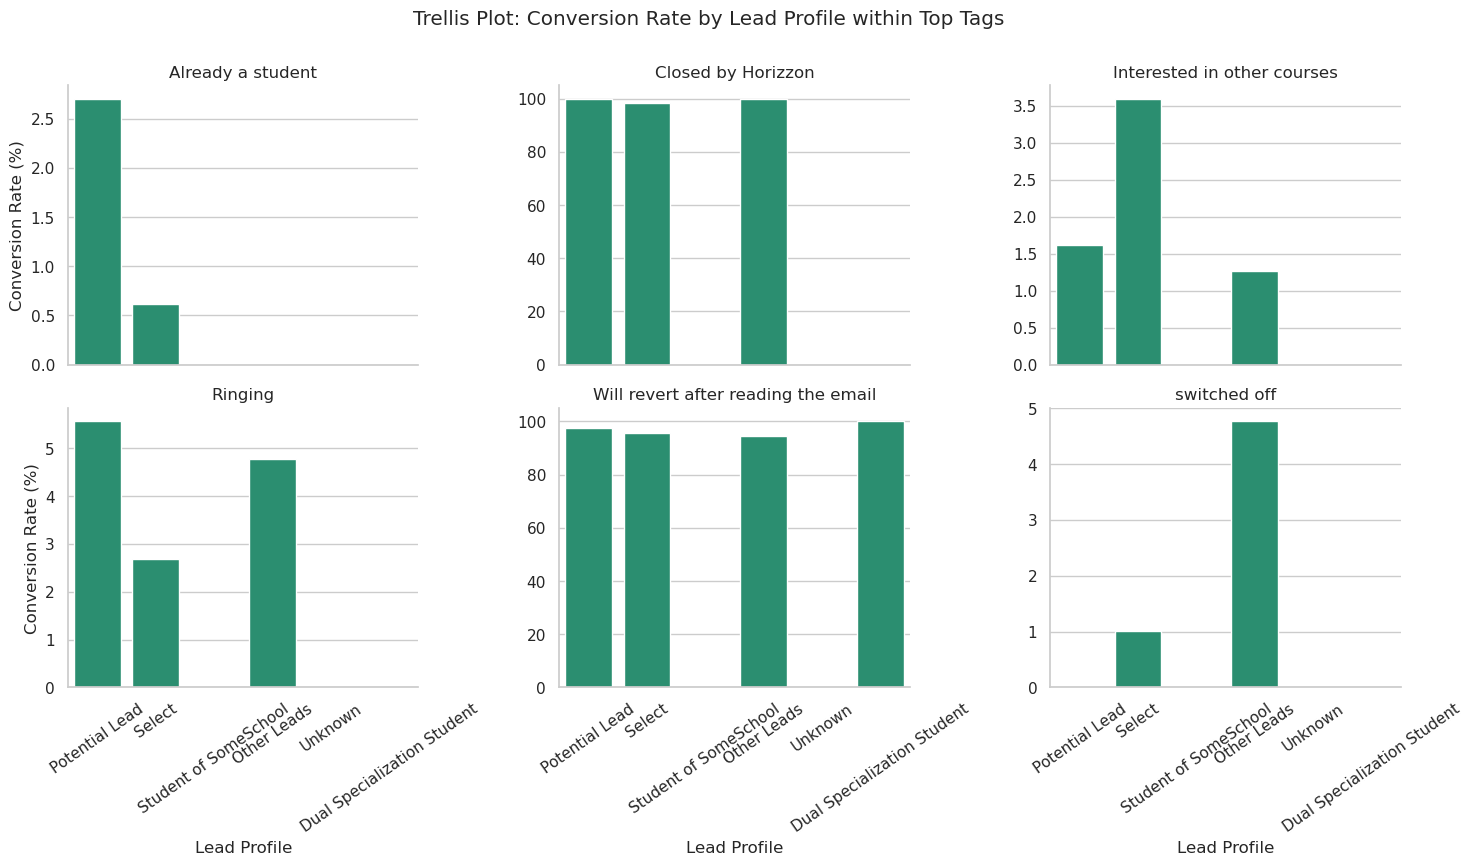


Top Tags duoc dua vao Trellis Plot: ['Will revert after reading the email', 'Ringing', 'Interested in other courses', 'Already a student', 'Closed by Horizzon', 'switched off']


In [ ]:
# Phan tich Tags + Lead Profile + Converted
tag_col = 'Tags'
profile_col = 'Lead Profile'

tag_df = df[[tag_col, profile_col, conv_col]].copy()
tag_df[tag_col] = tag_df[tag_col].fillna('Unknown').astype(str).str.strip()
tag_df[profile_col] = tag_df[profile_col].fillna('Unknown').astype(str).str.strip()
tag_df[conv_col] = pd.to_numeric(tag_df[conv_col], errors='coerce').fillna(0).astype(int)

# Tong hop theo cap Tag x Lead Profile
tag_profile_summary = (
    tag_df.groupby([tag_col, profile_col])
    .agg(
        total_leads=(conv_col, 'size'),
        converted_leads=(conv_col, 'sum')
    )
    .reset_index()
)
tag_profile_summary['conversion_rate_pct'] = (
    tag_profile_summary['converted_leads'] / tag_profile_summary['total_leads'] * 100
)

# Loc theo kich thuoc mau toi thieu de ket qua on dinh
min_tag_profile_size = 20
tag_profile_filtered = tag_profile_summary[
    tag_profile_summary['total_leads'] >= min_tag_profile_size
].copy()

print('=== Top Tag x Lead Profile by Conversion Rate (n >= 20) ===')
display(
    tag_profile_filtered
    .sort_values(['conversion_rate_pct', 'converted_leads'], ascending=[False, False])
    .head(20)
)

# Kiem chung cap cu the: "Will revert after reading the email" + "Potential Lead"
example_pair = tag_profile_summary[
    (tag_profile_summary[tag_col].str.lower() == 'will revert after reading the email') &
    (tag_profile_summary[profile_col].str.lower() == 'potential lead')
]

print('\n=== Check specific pair: Will revert after reading the email + Potential Lead ===')
if not example_pair.empty:
    ex = example_pair.iloc[0]
    print(
        f"Total Leads: {int(ex['total_leads'])}, "
        f"Converted: {int(ex['converted_leads'])}, "
        f"Conversion Rate: {ex['conversion_rate_pct']:.2f}%"
    )
else:
    print('Khong tim thay cap Tag/Profile nay trong du lieu.')

# Trellis Plot: so sanh conversion rate theo Lead Profile trong tung Tag quan trong
# Chon top tags theo quy mo lead (bo qua Unknown de bieu do de doc hon)
valid_tags_df = tag_df[tag_df[tag_col].str.lower() != 'unknown'].copy()
top_tags = valid_tags_df[tag_col].value_counts().head(6).index.tolist()

trellis_df = tag_profile_filtered[tag_profile_filtered[tag_col].isin(top_tags)].copy()
trellis_df = trellis_df.sort_values([tag_col, 'conversion_rate_pct'], ascending=[True, False])

if trellis_df.empty:
    print('\nKhong du du lieu de ve Trellis Plot sau khi loc n >= 20.')
else:
    g = sns.catplot(
        data=trellis_df,
        kind='bar',
        x=profile_col,
        y='conversion_rate_pct',
        col=tag_col,
        col_wrap=3,
        sharey=False,
        height=3.8,
        aspect=1.25,
        color='#1b9e77'
    )
    g.set_axis_labels('Lead Profile', 'Conversion Rate (%)')
    g.set_titles(col_template='{col_name}')

    for ax in g.axes.flatten():
        ax.tick_params(axis='x', rotation=35)

    plt.subplots_adjust(top=0.88)
    g.fig.suptitle('Trellis Plot: Conversion Rate by Lead Profile within Top Tags')
    plt.show()

print('\nTop Tags duoc dua vao Trellis Plot:', top_tags)


### Giai thich bieu do Trellis Plot (Tags x Lead Profile)

- Moi o nho la 1 `Tag`; truc X la `Lead Profile`, truc Y la `Conversion Rate (%)`.
- Hai tag `Closed by Horizzon` va `Will revert after reading the email` co conversion rate rat cao (xap xi 95-100%) o nhieu profile, cho thay day la nhom lead chat luong cao.
- Cac tag `Already a student`, `Interested in other courses`, `Ringing`, `switched off` co conversion thap (chu yeu quanh 1-6%), phu hop chien luoc nuoi duong hon la chot nhanh.
- Trong cung 1 tag, conversion khac nhau theo tung lead profile; vi vay can toi uu thong diep theo profile, khong nen danh dong loat.
- Luu y: bieu do dang de `sharey=False`, moi o co thang Y rieng; khi so sanh giua cac o, nen doi chieu them bang so lieu tong hop va kich thuoc mau (`n >= 20`).

=> Ket luan: `Tag` la bien phan loai manh cho conversion; uu tien effort cho nhom tag conversion cao va tach chien luoc nurture cho nhom conversion thap.

## 5) Phan tich Tac dong cua Uu dai (Incentive Impact)

Bien phan tich:
- A free copy of Mastering The Interview
- Total Time Spent on Website
- Converted

Muc tieu:
- Danh gia viec tang tai lieu mien phi co lam tang thoi gian o lai website va kha nang chuyen doi hay khong.
- Phan biet truong hop uu dai thu hut nguoi dung chi de nhan qua nhung khong co y dinh mua.

Goi y trinh bay:
- So sanh trung binh/median Total Time Spent giua nhom nhan va khong nhan tai lieu.
- Ve Boxplot theo nhom uu dai, phan lop theo Converted.

=== Incentive Summary (Received vs Not Received) ===


,incentive_group,leads,avg_time_spent,median_time_spent,conversion_rate_pct
0,Not Received,4803,562.404539,329.0,42.161149
1,Received,2887,624.546935,386.0,35.677174



=== Time Spent by Incentive Group and Converted Status ===


,incentive_group,converted_label,leads,avg_time_spent,median_time_spent
0,Not Received,Not Converted,2778,392.656947,234.0
1,Not Received,Converted,2025,795.273086,900.0
2,Received,Not Converted,1857,422.701669,265.0
3,Received,Converted,1030,988.456311,1063.0


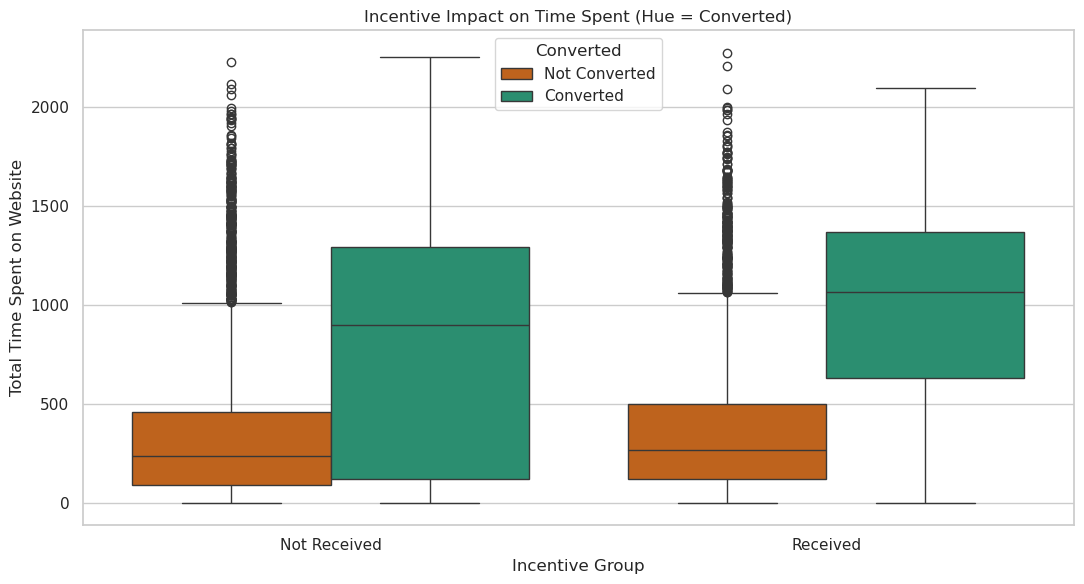


=== Quick Insight: Incentive Impact ===
Delta Avg Time (Received - Not Received): 62.14
Delta Conversion Rate (Received - Not Received): -6.48 percentage points
=> Uu dai lam tang thoi gian o lai, nhung chua chuyen hoa thanh chuyen doi.


In [ ]:
# Phan tich tac dong cua uu dai: free copy tai lieu
incentive_col = 'A free copy of Mastering The Interview'
time_col = 'Total Time Spent on Website'

incentive_df = df[[incentive_col, time_col, conv_col]].copy()
incentive_df[time_col] = pd.to_numeric(incentive_df[time_col], errors='coerce').fillna(0)
incentive_df[conv_col] = pd.to_numeric(incentive_df[conv_col], errors='coerce').fillna(0).astype(int)

# Chuan hoa nhom uu dai ve 2 muc: Received / Not Received
raw_incentive = incentive_df[incentive_col].fillna('Unknown').astype(str).str.strip().str.lower()
received_tokens = {'yes', '1', 'true', 'received', 'y'}
not_received_tokens = {'no', '0', 'false', 'not received', 'n'}

incentive_df['incentive_group'] = raw_incentive.apply(
    lambda x: 'Received' if x in received_tokens else ('Not Received' if x in not_received_tokens else 'Unknown')
)
incentive_df['converted_label'] = incentive_df[conv_col].map({0: 'Not Converted', 1: 'Converted'})

# Neu Unknown qua it, loai bo khoi bieu do de de doc
plot_incentive_df = incentive_df[incentive_df['incentive_group'].isin(['Received', 'Not Received'])].copy()

# Tong hop thong ke chinh
incentive_summary = (
    plot_incentive_df.groupby('incentive_group')
    .agg(
        leads=(conv_col, 'size'),
        avg_time_spent=(time_col, 'mean'),
        median_time_spent=(time_col, 'median'),
        conversion_rate_pct=(conv_col, 'mean')
    )
    .reset_index()
)
incentive_summary['conversion_rate_pct'] = incentive_summary['conversion_rate_pct'] * 100

print('=== Incentive Summary (Received vs Not Received) ===')
display(incentive_summary)

# So sanh chi tiet theo trang thai Converted
incentive_conv_summary = (
    plot_incentive_df.groupby(['incentive_group', conv_col])
    .agg(
        leads=(conv_col, 'size'),
        avg_time_spent=(time_col, 'mean'),
        median_time_spent=(time_col, 'median')
    )
    .reset_index()
)
incentive_conv_summary['converted_label'] = incentive_conv_summary[conv_col].map({1: 'Converted', 0: 'Not Converted'})

print('\n=== Time Spent by Incentive Group and Converted Status ===')
display(incentive_conv_summary[['incentive_group', 'converted_label', 'leads', 'avg_time_spent', 'median_time_spent']])

# Boxplot: phan bo time spent theo uu dai, phan lop theo Converted
plt.figure(figsize=(11, 6))
sns.boxplot(
    data=plot_incentive_df,
    x='incentive_group',
    y=time_col,
    hue='converted_label',
    hue_order=['Not Converted', 'Converted'],
    palette={'Not Converted': '#d95f02', 'Converted': '#1b9e77'}
)
plt.title('Incentive Impact on Time Spent (Hue = Converted)')
plt.xlabel('Incentive Group')
plt.ylabel('Total Time Spent on Website')
plt.legend(title='Converted')
plt.tight_layout()
plt.show()

# Insight nhanh
if set(incentive_summary['incentive_group']) == {'Received', 'Not Received'}:
    tmp = incentive_summary.set_index('incentive_group')
    delta_time = tmp.loc['Received', 'avg_time_spent'] - tmp.loc['Not Received', 'avg_time_spent']
    delta_conv = tmp.loc['Received', 'conversion_rate_pct'] - tmp.loc['Not Received', 'conversion_rate_pct']

    print('\n=== Quick Insight: Incentive Impact ===')
    print(f"Delta Avg Time (Received - Not Received): {delta_time:.2f}")
    print(f"Delta Conversion Rate (Received - Not Received): {delta_conv:.2f} percentage points")

    if delta_time > 0 and delta_conv > 0:
        print('=> Uu dai co dau hieu tich cuc cho ca muc do engagement va conversion.')
    elif delta_time > 0 and delta_conv <= 0:
        print('=> Uu dai lam tang thoi gian o lai, nhung chua chuyen hoa thanh chuyen doi.')
    elif delta_time <= 0 and delta_conv > 0:
        print('=> Uu dai ho tro conversion, du khong lam tang thoi gian o lai.')
    else:
        print('=> Uu dai chua cho thay tac dong tich cuc ro rang tren du lieu hien tai.')
else:
    print('\nKhong du du lieu Received/Not Received de ket luan day du.')


### Giai thich bieu do Boxplot (Incentive Impact)

- Bieu do so sanh phan bo `Total Time Spent on Website` theo 2 nhom uu dai: `Received` va `Not Received`, dong thoi tach theo trang thai `Converted`/`Not Converted`.
- O ca hai nhom uu dai, lead `Converted` co median time spent cao hon ro ret so voi `Not Converted`, cho thay muc do engagement gan lien voi kha nang chuyen doi.
- Nhom `Received` co xu huong median time spent cao hon nhom `Not Received` (dac biet trong tap `Converted`), goi y uu dai co the giup tang muc do o lai website.
- Tuy nhien do phan tan lon va nhieu outlier (cac diem o cao), can doi chieu them voi conversion rate trung binh de ket luan tac dong nhan qua theo huong nhan qua-thuc su mua hang.

=> Ket luan: uu dai co dau hieu cai thien engagement, nhung can danh gia dong thoi ca `time spent` va `conversion rate` de xac nhan hieu qua kinh doanh thuc su.